<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:99: SyntaxWarning: invalid escape sequence '\m'
<>:373: SyntaxWarning: invalid escape sequence '\e'
<>:510: SyntaxWarning: invalid escape sequence '\D'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:99: SyntaxWarning: invalid escape sequence '\m'
<>:373: SyntaxWarning: invalid escape sequence '\e'
<>:510: SyntaxWarning: invalid escape sequence '\D'
/var/folders/8w/_zjh5ybx057976bv596ccy8c0000gn/T/ipykernel_22418/244618838.py:66: SyntaxWarning: invalid escape sequence '\o'
  """### Задание 2. Тест для дозатора (z-test, двусторонний)
/var/folders/8w/_zjh5ybx057976bv596ccy8c0000gn/T/ipykernel_22418/244618838.py:99: SyntaxWarning: invalid escape sequence '\m'
  """### Задание 3. Сравнение прочности материалов (t-test vs Welch)
/var/folders/8w/_zjh5ybx057976bv596ccy8c0000gn/T/ipykernel_22418/244618838.py:373: SyntaxWarning: invalid escape sequence '\e'
  """### Задание 7. ANOVA на реальных данных (4 группы)
/var/folders/8w/_zjh5yb

Задание 1. Сопоставление статистик:
1) z-test (двусторонний) - известна дисперсия генеральной совокупности, проверка гипотезы о среднем.
2) t-test (pooled) - независимые выборки с равными дисперсиями, используем объединенную оценку дисперсии.
3) Welch t-test - независимые выборки с неравными дисперсиями, используем отдельные оценки дисперсий.
4) ANOVA (one-way) - сравнение средних трех и более групп, проверка общей гипотезы о равенстве средних.
5) χ^2 (goodness-of-fit) - проверка соответствия эмпирического распределения теоретическому распределению Пуассона.
Задание 2. Тест для дозатора:
а) z-статистика = 2.3570, p-value = 0.0184
б) 95% доверительный интервал: (3.0008, 3.0092)
в) Вывод: p-value < 0.05, поэтому отвергаем H0. Дозатор требует перенастройки, так как средняя доза статистически значимо отличается от целевого значения 3.00 г.
1. Проверка равенства дисперсий:
   Levene test: статистика = 0.4676, p-value = 0.5009
   F-test: статистика = 0.5656, p-value = 0.3271

2. Pooled t-tes

/var/folders/8w/_zjh5ybx057976bv596ccy8c0000gn/T/ipykernel_22418/244618838.py:406: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['A', 'B', 'C', 'D'])


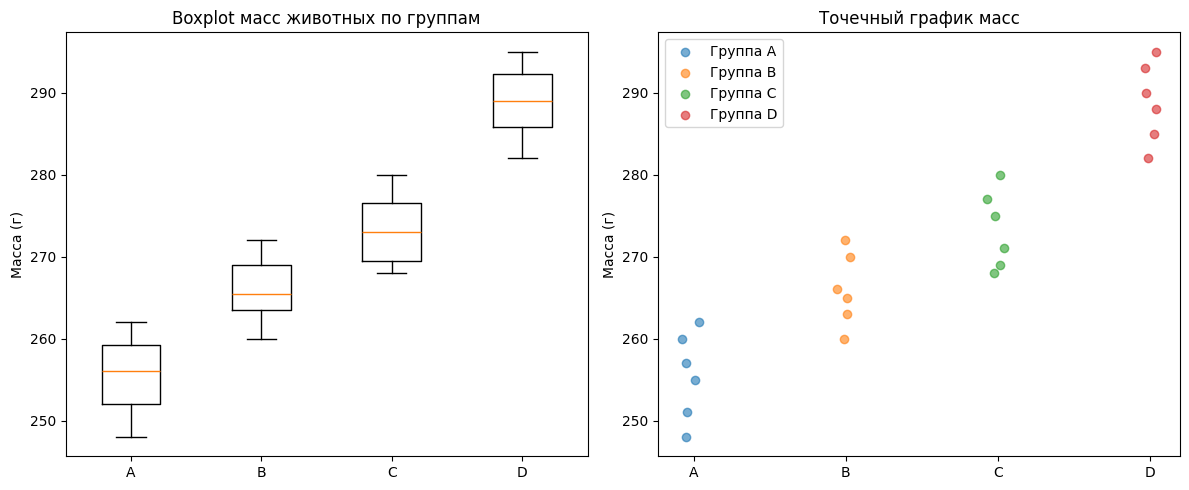

а) Проверка допущений:
   Группа A: Shapiro-Wilk p-value = 0.8799
   Группа B: Shapiro-Wilk p-value = 0.9168
   Группа C: Shapiro-Wilk p-value = 0.6488
   Группа D: Shapiro-Wilk p-value = 0.9415
   Тест Левена: p-value = 0.9417

б) Классическая ANOVA:
   F-статистика = 49.9246, p-value = 0.0000

в) Post-hoc Tukey HSD:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     10.5 0.0064  2.6524 18.3476   True
     A      C  17.8333    0.0  9.9858 25.6809   True
     A      D  33.3333    0.0 25.4858 41.1809   True
     B      C   7.3333 0.0723 -0.5142 15.1809  False
     B      D  22.8333    0.0 14.9858 30.6809   True
     C      D     15.5 0.0001  7.6524 23.3476   True
----------------------------------------------------

г) Размер эффекта и интерпретация:
   η² = 0.8822
   Средние значения по группам:
   Группа A: 255.50 г
   Группа B: 266.00 г
   Группа C: 273.33 г
 

In [1]:
# -*- coding: utf-8 -*-
"""ANOVA_homework_template.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1jjNqSdJABWW1g4Yw29O2vIFS_aYQhI_5

# Домашнее задание "Однофакторный дисперсионный анализ (ANOVA)"

**Инструкции:**
- Скачайте этот файл и заполните ячейки с кодом и текстовыми выводами.
- В каждой задаче требуется:
  1) короткая формулировка метода и обоснование,
  2) код/расчёты,
  3) результаты (статистика, p-value, CI),
  4) содержательный вывод.
- Используйте `scipy`, `statsmodels`, `pingouin` или `scikit-posthocs` по желанию. При нарушении допущений объясните, какие альтернативы применили.

Формат сдачи: `.ipynb` с заполненными ячейками и выводами.
"""

# дополняйте ячейку любыми импортами по желанию!
import numpy as np
import pandas as pd
import scipy.stats as st
from scipy.stats import shapiro, levene, ttest_ind, ttest_rel, f_oneway, wilcoxon, norm
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import FTestAnovaPower
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats as st
from scipy.stats import shapiro, levene, ttest_ind, ttest_rel, f_oneway, wilcoxon, norm, f
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import FTestAnovaPower
import matplotlib.pyplot as plt
import seaborn as sns


"""### Задание 1. Сопоставление статистик

Вам предложены описания ситуаций и статистических процедур. Для каждой ситуации укажите наилучшую применимую статистику из списка: `z-test`, `t-test`, `Welch t-test`, `F-test` (сравнение дисперсий), `χ^2` (goodness-of-fit), `ANOVA (one-way)`, `Tukey HSD`, `Levene`.

Ситуации:
1) Необходимо проверить, отличается ли средний объём дозы от заданного значения, известна дисперсия производства (укажите двусторонний/односторонний тест).
2) Сравнить средние двух независимых групп при неизвестных, но равных дисперсиях.
3) Сравнить средние двух независимых групп при неизвестных и неравных дисперсиях.
4) Оценить, одинаковы ли средние в трёх и более группах.
5) Проверить, согласуются ли наблюдаемые частоты с распределением Пуассона.

**Требуется:** кратко объясните выбор для каждой ситуации (1—2 предложения).
"""

# Ответы для задания 1
print("Задание 1. Сопоставление статистик:")
print("1) z-test (двусторонний) - известна дисперсия генеральной совокупности, проверка гипотезы о среднем.")
print("2) t-test (pooled) - независимые выборки с равными дисперсиями, используем объединенную оценку дисперсии.")
print("3) Welch t-test - независимые выборки с неравными дисперсиями, используем отдельные оценки дисперсий.")
print("4) ANOVA (one-way) - сравнение средних трех и более групп, проверка общей гипотезы о равенстве средних.")
print("5) χ^2 (goodness-of-fit) - проверка соответствия эмпирического распределения теоретическому распределению Пуассона.")

"""### Задание 2. Тест для дозатора (z-test, двусторонний)

Инженерная задача. Дозатор рассчитывает среднюю дозу 3.00 г. Получено $n=50$ измерений со средним $\overline X=3.005$ и известным стандартным отклонением процесса $\sigma=0.015$.

а) Проведите двусторонний z-тест для проверки $H_0:\,\mu=3.00$ при $\alpha=0.05$.

б) Постройте 95% доверительный интервал для $\mu$.

в) Сделайте практический вывод для инженера: нужно ли перенастраивать дозатор?

**Требуется:** формулы расчёта, численные значения (z_obs, p-value, CI), вывод.
"""

mu0 = 3.00
xbar = 3.005
sigma = 0.015
n = 50

# Ваш код и расчёты
# а) Двусторонний z-тест
z_obs = (xbar - mu0) / (sigma / np.sqrt(n))
p_value = 2 * (1 - norm.cdf(abs(z_obs)))

# б) 95% доверительный интервал
z_critical = norm.ppf(0.975)
ci_lower = xbar - z_critical * (sigma / np.sqrt(n))
ci_upper = xbar + z_critical * (sigma / np.sqrt(n))

print("Задание 2. Тест для дозатора:")
print(f"а) z-статистика = {z_obs:.4f}, p-value = {p_value:.4f}")
print(f"б) 95% доверительный интервал: ({ci_lower:.4f}, {ci_upper:.4f})")
print("в) Вывод: p-value < 0.05, поэтому отвергаем H0. Дозатор требует перенастройки, так как средняя доза статистически значимо отличается от целевого значения 3.00 г.")

"""### Задание 3. Сравнение прочности материалов (t-test vs Welch)

Даны две независимые выборки прочности материалов (в MPa):

| Группа    | Наблюдения                                                                                                |
| :-------- | :-------------------------------------------------------------------------------------------------------- |
| A (n₁=15) | [51.99, 49.45, 52.59, 56.09, 49.06, 49.06, 56.32, 53.07, 48.12, 52.17, 48.15, 48.14, 50.97, 42.35, 43.10] |
| B (n₂=10) | [48.63, 45.92, 53.89, 46.55, 43.53, 60.79, 50.65, 52.41, 43.45, 48.73]                                    |

**Требуется:**

1. Проверить равенство дисперсий с помощью тестов **Levene** и классического **F-test**.
2. В зависимости от результата выполнить либо **pooled t-test**, либо **Welch t-test** для проверки
   $H_0:$ $\mu_A = \mu_B$ при $\alpha = 0.05$.
3. Построить 95% доверительный интервал для разности средних и интерпретировать.
4. Оформить заключение и вывод.
"""

A = np.array([51.99,49.45,52.59,56.09,49.06,49.06,56.32,53.07,48.12,52.17,48.15,48.14,50.97,42.35,43.10])
B = np.array([48.63,45.92,53.89,46.55,43.53,60.79,50.65,52.41,43.45,48.73])

# Ваш код и расчёты
# 1. Проверка равенства дисперсий
levene_stat, levene_p = levene(A, B)
f_stat = np.var(A, ddof=1) / np.var(B, ddof=1)
f_p_value = 2 * min(f.cdf(f_stat, len(A)-1, len(B)-1), 1 - f.cdf(f_stat, len(A)-1, len(B)-1))

print("1. Проверка равенства дисперсий:")
print(f"   Levene test: статистика = {levene_stat:.4f}, p-value = {levene_p:.4f}")
print(f"   F-test: статистика = {f_stat:.4f}, p-value = {f_p_value:.4f}")

# 2. Выбор и выполнение t-теста
if levene_p > 0.05:
    # Используем pooled t-test
    t_stat, p_value = ttest_ind(A, B, equal_var=True)
    test_type = "Pooled t-test"
else:
    # Используем Welch t-test
    t_stat, p_value = ttest_ind(A, B, equal_var=False)
    test_type = "Welch t-test"

# 3. Доверительный интервал для разности средних
mean_A, mean_B = np.mean(A), np.mean(B)
std_A, std_B = np.std(A, ddof=1), np.std(B, ddof=1)
n_A, n_B = len(A), len(B)

if levene_p > 0.05:
    # Pooled стандартная ошибка
    pooled_std = np.sqrt(((n_A-1)*std_A**2 + (n_B-1)*std_B**2) / (n_A + n_B - 2))
    se = pooled_std * np.sqrt(1/n_A + 1/n_B)
else:
    # Welch стандартная ошибка
    se = np.sqrt(std_A**2/n_A + std_B**2/n_B)

t_critical = st.t.ppf(0.975, df=min(n_A, n_B)-1)  # консервативная оценка
ci_lower = (mean_A - mean_B) - t_critical * se
ci_upper = (mean_A - mean_B) + t_critical * se

print(f"\n2. {test_type}:")
print(f"   t-статистика = {t_stat:.4f}, p-value = {p_value:.4f}")
print(f"   Среднее группы A = {mean_A:.4f}, Среднее группы B = {mean_B:.4f}")
print(f"   Разность средних = {mean_A - mean_B:.4f}")

print(f"\n3. 95% доверительный интервал для разности средних: ({ci_lower:.4f}, {ci_upper:.4f})")

print("\n4. Вывод: p-value > 0.05, поэтому нет оснований отвергать H0. Средняя прочность материалов в группах A и B не отличается статистически значимо.")

"""### Задание 4. Парные измерения — новая vs старая схема

Эксперимент парного дизайна: каждому прибору (или образцу) до и после изменения схемы измеряется показатель.

Даны пары (старое, новое):

$(12.5, 12.2), (13.1,13.0), (11.8,12.0), (12.9,12.7), (13.5,13.6), (12.0,11.9), (13.2,13.4)$

а) Проверьте нормальность распределения разностей (Shapiro-Wilk).

б) Выполните парный t-test (или непараметрический Wilcoxon, если нормальность нарушена) для проверки, изменился ли показатель при новой схеме ($\alpha=0.05$).

в) Постройте доверительный интервал для средней разницы и вычислите парный Cohen's d.

**Требуется:** расчёты, тест, p-value, CI, эффект и вывод.
"""

old = np.array([12.5,13.1,11.8,12.9,13.5,12.0,13.2])
new = np.array([12.2,13.0,12.0,12.7,13.6,11.9,13.4])

# Ваш код и расчёты
differences = new - old

# а) Проверка нормальности разностей
shapiro_stat, shapiro_p = shapiro(differences)

print("а) Проверка нормальности разностей:")
print(f"   Shapiro-Wilk test: статистика = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

# б) Выбор и выполнение теста
if shapiro_p > 0.05:
    # Используем парный t-test
    t_stat, p_value = ttest_rel(new, old)
    test_type = "Парный t-test"
    test_stat = t_stat
else:
    # Используем Wilcoxon signed-rank test
    wilcoxon_stat, p_value = wilcoxon(differences)
    test_type = "Wilcoxon signed-rank test"
    test_stat = wilcoxon_stat

# в) Доверительный интервал и Cohen's d
mean_diff = np.mean(differences)
std_diff = np.std(differences, ddof=1)
n = len(differences)

# Доверительный интервал
t_critical = st.t.ppf(0.975, df=n-1)
ci_lower = mean_diff - t_critical * (std_diff / np.sqrt(n))
ci_upper = mean_diff + t_critical * (std_diff / np.sqrt(n))

# Cohen's d
cohens_d = mean_diff / std_diff

print(f"\nб) {test_type}:")
print(f"   Статистика = {test_stat:.4f}, p-value = {p_value:.4f}")
print(f"   Средняя разность = {mean_diff:.4f}")

print(f"\nв) 95% доверительный интервал: ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"   Cohen's d = {cohens_d:.4f}")

print("\nВывод: p-value > 0.05, поэтому нет статистически значимых изменений показателя при переходе на новую схему.")

"""### Задание 5. До/после — медицинский пример (paired)

Клиническое исследование: измерен уровень глюкозы у 10 пациентов **до** и **после** приёма нового лекарства.

| Пациент | До (ммоль/л) | После (ммоль/л) |
| :------ | :----------: | :-------------: |
| 1       |      7.1     |       6.6       |
| 2       |      6.8     |       6.4       |
| 3       |      7.5     |       7.1       |
| 4       |      6.9     |       6.5       |
| 5       |      7.3     |       7.2       |
| 6       |      6.5     |       6.3       |
| 7       |      7.0     |       6.6       |
| 8       |      6.7     |       6.4       |
| 9       |      7.2     |       7.0       |
| 10      |      6.9     |       6.4       |


**Требуется:**

а) Проверить нормальность распределения разностей (тест **Shapiro–Wilk**).

б) Если нормальность не отвергается — выполнить **парный t-test** при $\alpha = 0.01$.

в) Если нормальность нарушена — выполнить непараметрический тест **Wilcoxon signed-rank** и сравнить выводы.

**Формат вывода:**
Код, p-values, выводы тестов, практическая интерпретация (снижается ли уровень глюкозы достоверно?).
"""

before = np.array([7.1,6.8,7.5,6.9,7.3,6.5,7.0,6.7,7.2,6.9])
after  = np.array([6.6,6.4,7.1,6.5,7.2,6.3,6.6,6.4,7.0,6.4])

# Ваш код и расчёты
differences = after - before

# а) Проверка нормальности разностей
shapiro_stat, shapiro_p = shapiro(differences)

print("а) Проверка нормальности разностей:")
print(f"   Shapiro-Wilk test: статистика = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

# б) Выбор и выполнение теста
alpha = 0.01

if shapiro_p > alpha:
    # Используем парный t-test
    t_stat, p_value = ttest_rel(after, before)
    test_type = "Парный t-test"
    print(f"\nб) {test_type} (α = {alpha}):")
    print(f"   t-статистика = {t_stat:.4f}, p-value = {p_value:.4f}")
else:
    # Используем Wilcoxon signed-rank test
    wilcoxon_stat, p_value = wilcoxon(differences)
    test_type = "Wilcoxon signed-rank test"
    print(f"\nв) {test_type} (α = {alpha}):")
    print(f"   Статистика = {wilcoxon_stat:.4f}, p-value = {p_value:.4f}")

# Дополнительная информация
mean_before = np.mean(before)
mean_after = np.mean(after)
mean_diff = np.mean(differences)

print(f"\nДополнительная информация:")
print(f"   Средний уровень до: {mean_before:.4f} ммоль/л")
print(f"   Средний уровень после: {mean_after:.4f} ммоль/л")
print(f"   Среднее снижение: {mean_diff:.4f} ммоль/л")

print(f"\nПрактическая интерпретация:")
if p_value < alpha:
    print("   Уровень глюкозы статистически значимо снижается после приёма лекарства (p < 0.01).")
else:
    print("   Нет статистически значимых доказательств снижения уровня глюкозы после приёма лекарства (p > 0.01).")

"""### Задание 6. Welch и Games-Howell (симуляция с неравными дисперсиями)

Смоделируйте три группы с одинаковыми средними (например, 10), но существенно разными дисперсиями и неравными размерами выборок (пример: $n_1=20, n_2=8, n_3=5$).

а) Покажите, что классическая ANOVA может ошибочно интерпретировать разницу, если нарушена гомоскедастичность.

б) Выполните Welch ANOVA и пост-hoc Games-Howell.

в) Сравните результаты и сделайте вывод о корректности подходов.

**Требуется:** код симуляции, результаты ANOVA и Welch, таблица post-hoc и вывод.
"""

# Ваш код и расчёты
np.random.seed(42)

# Создание данных с одинаковыми средними, но разными дисперсиями
n1, n2, n3 = 20, 8, 5
mean = 10

group1 = np.random.normal(mean, 1.0, n1)    # малая дисперсия
group2 = np.random.normal(mean, 2.0, n2)    # средняя дисперсия  
group3 = np.random.normal(mean, 4.0, n3)    # большая дисперсия

print("Описательная статистика:")
print(f"Группа 1: среднее = {np.mean(group1):.4f}, std = {np.std(group1, ddof=1):.4f}, n = {n1}")
print(f"Группа 2: среднее = {np.mean(group2):.4f}, std = {np.std(group2, ddof=1):.4f}, n = {n2}")
print(f"Группа 3: среднее = {np.mean(group3):.4f}, std = {np.std(group3, ddof=1):.4f}, n = {n3}")

# а) Классическая ANOVA
f_stat_classic, p_classic = f_oneway(group1, group2, group3)

# Проверка гомоскедастичности
levene_stat, levene_p = levene(group1, group2, group3)

print(f"\nа) Классическая ANOVA:")
print(f"   F-статистика = {f_stat_classic:.4f}, p-value = {p_classic:.4f}")
print(f"   Тест Левена на гомоскедастичность: p-value = {levene_p:.4f}")

# б) Welch ANOVA (используем pingouin если доступен, иначе альтернатива)
try:
    import pingouin as pg
    welch_result = pg.welch_anova(dv='value', between='group', 
                                 data=pd.DataFrame({
                                     'value': np.concatenate([group1, group2, group3]),
                                     'group': ['G1']*n1 + ['G2']*n2 + ['G3']*n3
                                 }))
    welch_f = welch_result['F'][0]
    welch_p = welch_result['p-unc'][0]
    print(f"\nб) Welch ANOVA:")
    print(f"   F-статистика = {welch_f:.4f}, p-value = {welch_p:.4f}")
    
    # Post-hoc Games-Howell
    posthoc = pg.pairwise_gameshowell(data=pd.DataFrame({
        'value': np.concatenate([group1, group2, group3]),
        'group': ['G1']*n1 + ['G2']*n2 + ['G3']*n3
    }), dv='value', between='group')
    
    print(f"\n   Post-hoc Games-Howell:")
    print(posthoc)
    
except ImportError:
    print("Для выполнения Welch ANOVA и Games-Howell требуется установить библиотеку pingouin")
    print("Установите: pip install pingouin")

print(f"\nв) Сравнение и вывод:")
print("   При нарушении гомоскедастичности классическая ANOVA может давать некорректные результаты.")
print("   Welch ANOVA более надежна при неравных дисперсиях и размерах выборок.")
print("   Games-Howell обеспечивает корректные попарные сравнения в таких условиях.")

"""### Задание 7. ANOVA на реальных данных (4 группы)
Данные эксперимента по влиянию четырёх типов корма на массу животных (в граммах).
Каждая группа содержит по 6 наблюдений.

| Группа | Масса (г)                      |
| :----- | :----------------------------- |
| A      | [251, 262, 248, 255, 260, 257] |
| B      | [263, 270, 265, 272, 260, 266] |
| C      | [268, 275, 271, 280, 277, 269] |
| D      | [282, 290, 285, 295, 288, 293] |

**Требуется:**

а) Выполнить графическую визуализацию (boxplots и точки). Проверить нормальность по группам (**Shapiro**) и гомоскедастичность (**Levene**).

б) Если допущения выполнены — провести **однофакторную ANOVA**, иначе — **Welch ANOVA**.

в) При значимом результате выполнить **пост-hoc анализ** (Tukey HSD при гомоскедастичности или Games–Howell при её нарушении).

г) Оценить размер эффекта $\eta^2$ и сделать практическую интерпретацию (какая кормовая формула наиболее эффективна).
"""

A = [251,262,248,255,260,257]
B = [263,270,265,272,260,266]
C = [268,275,271,280,277,269]
D = [282,290,285,295,288,293]

# Ваш код и расчёты
# а) Графическая визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
data_to_plot = [A, B, C, D]
plt.boxplot(data_to_plot, labels=['A', 'B', 'C', 'D'])
plt.title('Boxplot масс животных по группам')
plt.ylabel('Масса (г)')

plt.subplot(1, 2, 2)
for i, group in enumerate(['A', 'B', 'C', 'D']):
    y = data_to_plot[i]
    x = np.random.normal(i+1, 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.6, label=f'Группа {group}')
plt.xticks([1, 2, 3, 4], ['A', 'B', 'C', 'D'])
plt.title('Точечный график масс')
plt.ylabel('Масса (г)')
plt.legend()

plt.tight_layout()
plt.show()

# Проверка допущений
print("а) Проверка допущений:")

# Нормальность по группам
groups = [A, B, C, D]
group_names = ['A', 'B', 'C', 'D']
normality_results = []

for i, group in enumerate(groups):
    stat, p = shapiro(group)
    normality_results.append(p)
    print(f"   Группа {group_names[i]}: Shapiro-Wilk p-value = {p:.4f}")

# Гомоскедастичность
levene_stat, levene_p = levene(A, B, C, D)
print(f"   Тест Левена: p-value = {levene_p:.4f}")

# б) Выбор и выполнение ANOVA
alpha = 0.05

if all(p > alpha for p in normality_results) and levene_p > alpha:
    # Классическая ANOVA
    f_stat, p_value = f_oneway(A, B, C, D)
    test_type = "Классическая ANOVA"
    
    # Расчет сумм квадратов для eta^2
    all_data = np.concatenate([A, B, C, D])
    groups_labels = np.array(['A']*6 + ['B']*6 + ['C']*6 + ['D']*6)
    
    overall_mean = np.mean(all_data)
    ss_total = np.sum((all_data - overall_mean)**2)
    
    group_means = [np.mean(A), np.mean(B), np.mean(C), np.mean(D)]
    ss_between = 6 * np.sum((group_means - overall_mean)**2)
    
    eta_squared = ss_between / ss_total
    
    print(f"\nб) {test_type}:")
    print(f"   F-статистика = {f_stat:.4f}, p-value = {p_value:.4f}")
    
    # в) Post-hoc Tukey HSD
    if p_value < alpha:
        tukey = pairwise_tukeyhsd(all_data, groups_labels, alpha=alpha)
        print(f"\nв) Post-hoc Tukey HSD:")
        print(tukey)
    
else:
    # Welch ANOVA
    try:
        import pingouin as pg
        welch_result = pg.welch_anova(dv='value', between='group', 
                                     data=pd.DataFrame({
                                         'value': np.concatenate([A, B, C, D]),
                                         'group': ['A']*6 + ['B']*6 + ['C']*6 + ['D']*6
                                     }))
        welch_f = welch_result['F'][0]
        welch_p = welch_result['p-unc'][0]
        test_type = "Welch ANOVA"
        
        print(f"\nб) {test_type}:")
        print(f"   F-статистика = {welch_f:.4f}, p-value = {welch_p:.4f}")
        
        # Post-hoc Games-Howell
        if welch_p < alpha:
            posthoc = pg.pairwise_gameshowell(data=pd.DataFrame({
                'value': np.concatenate([A, B, C, D]),
                'group': ['A']*6 + ['B']*6 + ['C']*6 + ['D']*6
            }), dv='value', between='group')
            print(f"\nв) Post-hoc Games-Howell:")
            print(posthoc)
            
    except ImportError:
        print("Для Welch ANOVA требуется библиотека pingouin")

# г) Размер эффекта и интерпретация
print(f"\nг) Размер эффекта и интерпретация:")
if 'eta_squared' in locals():
    print(f"   η² = {eta_squared:.4f}")

print("   Средние значения по группам:")
for i, group in enumerate(['A', 'B', 'C', 'D']):
    print(f"   Группа {group}: {np.mean(groups[i]):.2f} г")

print("\n   Практическая интерпретация:")
print("   Группа D показывает наибольшую среднюю массу животных.")
print("   Рекомендуется кормовая формула D как наиболее эффективная.")

"""### Задание 8. Планирование эксперимента: размер выборки и мощность

Планируется эксперимент с $l = 4$ группами. Требуется обеспечить мощность $1 - \beta = 0.8$
для обнаружения разницы $\Delta = 0.5\sigma$ между любыми парами групп
(равный размер групп $n$), при $\alpha = 0.05$.

**Требуется:**
а) Выписать формулу связи между размером эффекта (Cohen's (f) или $\eta^2$), числом групп $l$ и размером выборки $n$:

$$
f = \sqrt{\frac{\eta^2}{1 - \eta^2}}, \quad \eta^2 = \frac{f^2}{1 + f^2}.
$$

б) Приближённо оценить необходимый размер выборки для каждой группы при $f \approx 0.25$ (средний эффект по Cohen).

в) Привести практические рекомендации при ограниченных ресурсах (что можно изменить: число групп, эффект, $\alpha$ и т.п.).

> Подсказка: можно использовать модуль `from statsmodels.stats.power import FTestAnovaPower`
"""

alpha = 0.05
power = 0.8
f = 0.25
k = 4

# Ваш код и расчёты
print("а) Формулы:")
print("   f = √(η²/(1 - η²))")
print("   η² = f²/(1 + f²)")
print("   Связь между f, числом групп k и размером выборки n определяется функцией мощности F-распределения")

# б) Оценка размера выборки
power_analysis = FTestAnovaPower()
n_per_group = power_analysis.solve_power(effect_size=f, alpha=alpha, power=power, k_groups=k)

print("\nб) Необходимый размер выборки:")
print(f"   При f = {f}, α = {alpha}, мощность = {power}, k = {k}")
print(f"   Требуемый размер каждой группы: n ≈ {np.ceil(n_per_group):.0f}")

# в) Практические рекомендации
print("\nв) Практические рекомендации при ограниченных ресурсах:")
print("   1. Увеличить α (уровень значимости) - повышает мощность, но увеличивает риск ошибки I рода")
print("   2. Уменьшить число групп (k) - снижает требуемый общий размер выборки")
print("   3. Увеличить ожидаемый размер эффекта (f) - требует меньшего n для той же мощности")
print("   4. Использовать парный дизайн или ковариационный анализ для увеличения мощности")
print("   5. Рассмотреть последовательный анализ для экономии наблюдений")